# Data pre-processing

In [1]:
import os
import numpy as np
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (Input, TimeDistributed, Conv1D, Dropout, Flatten,
                                     LSTM, Dense, Layer, GlobalAveragePooling1D)
from tensorflow.keras.models import Model


In [2]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = 'ASL Data'

actions = np.array([
    'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S',
    'T','U','V','W','X','Y','Z','Hello','Help','Yes','No','ThankYou'
])

label_map = {label: i for i, label in enumerate(actions)}

no_sequences = 30
sequence_length = 30
feature_dim = 126


In [3]:
class SelfAttention(Layer):
    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):
        d = input_shape[-1]
        self.Wq = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')
        self.Wk = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')
        self.Wv = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')

    def call(self, x):
        Q = tf.matmul(x, self.Wq)
        K = tf.matmul(x, self.Wk)
        V = tf.matmul(x, self.Wv)

        scores = tf.matmul(Q, K, transpose_b=True) / tf.sqrt(float(self.units))
        weights = tf.nn.softmax(scores, axis=-1)

        return tf.matmul(weights, V)


In [4]:
def load_dataset():
    sequences = []
    labels = []

    for action in actions:
        for seq in range(no_sequences):
            seq_path = os.path.join(DATA_PATH, action, str(seq))
            window = []

            for frame_num in range(sequence_length):
                fpath = os.path.join(seq_path, f"{frame_num}.npy")
                if os.path.exists(fpath):
                    kp = np.load(fpath)
                else:
                    kp = np.zeros((126,))
                window.append(kp)

            sequences.append(window)
            labels.append(label_map[action])

    X = np.array(sequences).astype(np.float32)
    y = to_categorical(labels, num_classes=len(actions))
    return X, y

X, y = load_dataset()
print("Dataset shape:", X.shape, y.shape)


Dataset shape: (930, 30, 126) (930, 31)


In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.05, shuffle=True, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.10, shuffle=True, random_state=SEED
)

# Normalization
mu = X_train.mean()
sigma = X_train.std() + 1e-9

X_train = (X_train - mu) / sigma
X_val   = (X_val   - mu) / sigma
X_test  = (X_test  - mu) / sigma

# Add channel dimension for Conv1D
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]


# Build Model

In [6]:
def build_model():
    inputs = Input(shape=(sequence_length, feature_dim, 1))

    x = TimeDistributed(Conv1D(64, 3, padding='same', activation='relu'))(inputs)
    x = TimeDistributed(Dropout(0.3))(x)

    x = TimeDistributed(Conv1D(128, 3, padding='same', activation='relu'))(x)
    x = TimeDistributed(Dropout(0.3))(x)

    x = TimeDistributed(Flatten())(x)

    x = LSTM(256, return_sequences=True)(x)

    x = SelfAttention(128)(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(len(actions), activation='softmax')(x)

    model = Model(inputs, outputs, name="CNN-LSTM")
    return model

model = build_model()
model.summary()


Model: "CNN-LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 126, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 126, 64)    │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 126, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 30, 126, 128)   │        24,704 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 126, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 30, 16128)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 256)        │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention (SelfAttention)  │ (None, 30, 128)        │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,922,015 (64.55 MB)

 Trainable params: 16,922,015 (64.55 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [7]:
checkpoint = ModelCheckpoint(
    "keypoint_cnn_lstm_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduceLR = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    callbacks=[checkpoint, early, reduceLR],
    shuffle=True,
    verbose=2
)

model.save("cnn_lstm_model.h5")
np.savez("cnnlstm_norm_stats.npz", mu=mu, sigma=sigma)


Epoch 1/60

Epoch 1: val_accuracy improved from -inf to 0.20225, saving model to keypoint_cnn_lstm_best.h5


50/50 - 42s - 834ms/step - accuracy: 0.0668 - loss: 3.4839 - val_accuracy: 0.2022 - val_loss: 2.9982 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_accuracy improved from 0.20225 to 0.39326, saving model to keypoint_cnn_lstm_best.h5


50/50 - 23s - 461ms/step - accuracy: 0.1562 - loss: 2.8859 - val_accuracy: 0.3933 - val_loss: 2.1660 - learning_rate: 0.0010
Epoch 3/60

Epoch 3: val_accuracy improved from 0.39326 to 0.51685, saving model to keypoint_cnn_lstm_best.h5


50/50 - 20s - 410ms/step - accuracy: 0.3275 - loss: 2.0653 - val_accuracy: 0.5169 - val_loss: 1.5144 - learning_rate: 0.0010
Epoch 4/60

Epoch 4: val_accuracy improved from 0.51685 to 0.55056, saving model to keypoint_cnn_lstm_best.h5


50/50 - 19s - 389ms/step - accuracy: 0.4395 - loss: 1.6781 - val_accuracy: 0.5506 - val_loss: 1.1848 - learning_rate: 0.0010
Epoch 5/60

Epoch 5: val_accuracy improved from 0.55056 to 0.74157, saving model to keypoint_cnn_lstm_best.h5


...

50/50 - 19s - 384ms/step - accuracy: 0.7443 - loss: 0.7329 - val_accuracy: 0.9101 - val_loss: 0.4075 - learning_rate: 0.0010
Epoch 9/60

Epoch 9: val_accuracy did not improve from 0.91011
50/50 - 18s - 368ms/step - accuracy: 0.8060 - loss: 0.6190 - val_accuracy: 0.9101 - val_loss: 0.4265 - learning_rate: 0.0010
Epoch 10/60

Epoch 10: val_accuracy did not improve from 0.91011
50/50 - 18s - 370ms/step - accuracy: 0.8363 - loss: 0.4885 - val_accuracy: 0.8315 - val_loss: 0.5662 - learning_rate: 0.0010
Epoch 11/60

Epoch 11: val_accuracy did not improve from 0.91011
50/50 - 24s - 487ms/step - accuracy: 0.8526 - loss: 0.4450 - val_accuracy: 0.8764 - val_loss: 0.4314 - learning_rate: 0.0010
Epoch 12/60

Epoch 12: val_accuracy improved from 0.91011 to 0.93258, saving model to keypoint_cnn_lstm_best.h5


50/50 - 24s - 487ms/step - accuracy: 0.8804 - loss: 0.3586 - val_accuracy: 0.9326 - val_loss: 0.3184 - learning_rate: 0.0010
Epoch 13/60

Epoch 13: val_accuracy did not improve from 0.93258
50/50 - 20s - 404ms/step - accuracy: 0.8980 - loss: 0.3213 - val_accuracy: 0.8876 - val_loss: 0.4003 - learning_rate: 0.0010
Epoch 14/60

Epoch 14: val_accuracy did not improve from 0.93258
50/50 - 18s - 368ms/step - accuracy: 0.9081 - loss: 0.3231 - val_accuracy: 0.9213 - val_loss: 0.3056 - learning_rate: 0.0010
Epoch 15/60

Epoch 15: val_accuracy did not improve from 0.93258
50/50 - 21s - 414ms/step - accuracy: 0.9005 - loss: 0.3255 - val_accuracy: 0.8876 - val_loss: 0.4720 - learning_rate: 0.0010
Epoch 16/60

Epoch 16: val_accuracy improved from 0.93258 to 0.94382, saving model to keypoint_cnn_lstm_best.h5


50/50 - 19s - 377ms/step - accuracy: 0.9395 - loss: 0.1694 - val_accuracy: 0.9438 - val_loss: 0.2370 - learning_rate: 0.0010
Epoch 17/60

Epoch 17: val_accuracy did not improve from 0.94382
50/50 - 19s - 377ms/step - accuracy: 0.9370 - loss: 0.1815 - val_accuracy: 0.9326 - val_loss: 0.2596 - learning_rate: 0.0010
Epoch 18/60

Epoch 18: val_accuracy did not improve from 0.94382
50/50 - 18s - 364ms/step - accuracy: 0.9345 - loss: 0.1839 - val_accuracy: 0.9326 - val_loss: 0.4706 - learning_rate: 0.0010
Epoch 19/60

Epoch 19: val_accuracy did not improve from 0.94382
50/50 - 18s - 363ms/step - accuracy: 0.9144 - loss: 0.2186 - val_accuracy: 0.9438 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 20/60

Epoch 20: val_accuracy did not improve from 0.94382
50/50 - 18s - 364ms/step - accuracy: 0.9660 - loss: 0.1125 - val_accuracy: 0.9438 - val_loss: 0.3764 - learning_rate: 0.0010
Epoch 21/60

Epoch 21: val_accuracy improved from 0.94382 to 0.97753, saving model to keypoint_cnn_lstm_best.h5



Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
50/50 - 19s - 381ms/step - accuracy: 0.9559 - loss: 0.1326 - val_accuracy: 0.9775 - val_loss: 0.2552 - learning_rate: 0.0010
Epoch 22/60

Epoch 22: val_accuracy did not improve from 0.97753
50/50 - 18s - 364ms/step - accuracy: 0.9736 - loss: 0.0669 - val_accuracy: 0.9551 - val_loss: 0.2149 - learning_rate: 5.0000e-04
Epoch 23/60

Epoch 23: val_accuracy improved from 0.97753 to 0.98876, saving model to keypoint_cnn_lstm_best.h5


50/50 - 19s - 373ms/step - accuracy: 0.9698 - loss: 0.0590 - val_accuracy: 0.9888 - val_loss: 0.1868 - learning_rate: 5.0000e-04
Epoch 24/60

Epoch 24: val_accuracy did not improve from 0.98876
50/50 - 18s - 360ms/step - accuracy: 0.9861 - loss: 0.0469 - val_accuracy: 0.9551 - val_loss: 0.2188 - learning_rate: 5.0000e-04
Epoch 25/60

Epoch 25: val_accuracy did not improve from 0.98876
50/50 - 18s - 366ms/step - accuracy: 0.9836 - loss: 0.0459 - val_accuracy: 0.9775 - val_loss: 0.2297 - learning_rate: 5.0000e-04
Epoch 26/60

Epoch 26: val_accuracy did not improve from 0.98876
50/50 - 18s - 359ms/step - accuracy: 0.9912 - loss: 0.0332 - val_accuracy: 0.9663 - val_loss: 0.2400 - learning_rate: 5.0000e-04
Epoch 27/60

Epoch 27: val_accuracy did not improve from 0.98876
50/50 - 18s - 364ms/step - accuracy: 0.9924 - loss: 0.0289 - val_accuracy: 0.9775 - val_loss: 0.2314 - learning_rate: 5.0000e-04
Epoch 28/60

Epoch 28: val_accuracy did not improve from 0.98876

Epoch 28: ReduceLROnPlateau r

# Model Evaluation

Accuracy : 0.9149
Precision: 0.9521
Recall   : 0.9149
F1-score : 0.9228
Avg inference time per sample: 109.11 ms

Detailed class report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       1.00      0.50      0.67         2
           C       1.00      1.00      1.00         2
           D       1.00      1.00      1.00         2
           E       1.00      1.00      1.00         1
           F       0.00      0.00      0.00         0
           G       1.00      1.00      1.00         2
           H       1.00      0.67      0.80         3
           I       0.50      1.00      0.67         1
           J       1.00      1.00      1.00         1
           K       1.00      1.00      1.00         2
           L       1.00      0.67      0.80         3
           M       1.00      1.00      1.00         3
           N       0.00      0.00      0.00         0
           O       0.00      0.00      0.00         

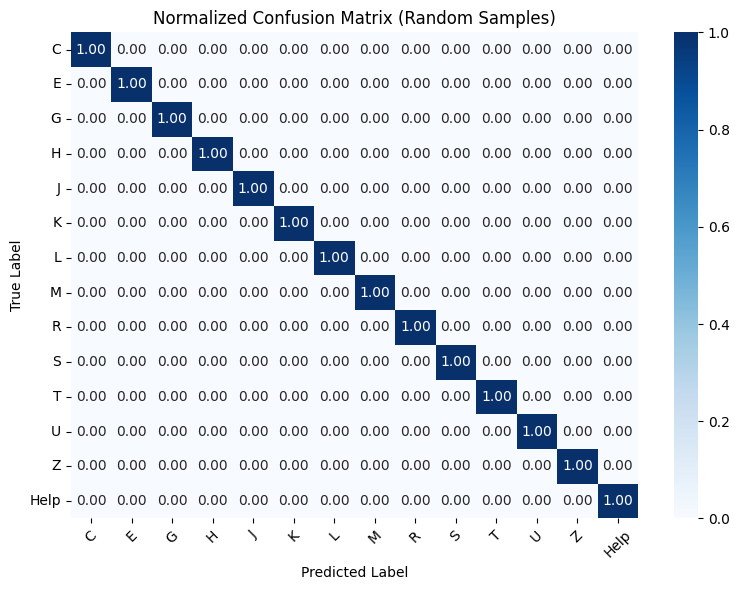

In [ ]:
import tensorflow as tf
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
import os

# Define dataset and load function
DATA_PATH = 'ASL Data'
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

actions = np.array([
    'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S',
    'T','U','V','W','X','Y','Z','Hello','Help','Yes','No','ThankYou'
])

label_map = {label: i for i, label in enumerate(actions)}

no_sequences = 30
sequence_length = 30
feature_dim = 126

def load_dataset():
    sequences = []
    labels = []
    for action in actions:
        for seq in range(no_sequences):
            seq_path = os.path.join(DATA_PATH, action, str(seq))
            window = []
            for frame_num in range(sequence_length):
                fpath = os.path.join(seq_path, f"{frame_num}.npy")
                if os.path.exists(fpath):
                    kp = np.load(fpath)
                else:
                    kp = np.zeros((126,))
                window.append(kp)
            sequences.append(window)
            labels.append(label_map[action])
    X = np.array(sequences).astype(np.float32)
    y = to_categorical(labels, num_classes=len(actions))
    return X, y

# Load dataset and split
X, y = load_dataset()
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.05, shuffle=True, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.10, shuffle=True, random_state=SEED
)

# Normalization
mu = X_train.mean()
sigma = X_train.std() + 1e-9
X_train = (X_train - mu) / sigma
X_val   = (X_val   - mu) / sigma
X_test  = (X_test  - mu) / sigma

# Add channel dimension for Conv1D
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# Define custom SelfAttention layer
class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs): 
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        d = input_shape[-1]
        self.Wq = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')
        self.Wk = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')
        self.Wv = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')

    def call(self, x):
        Q = tf.matmul(x, self.Wq)
        K = tf.matmul(x, self.Wk)
        V = tf.matmul(x, self.Wv)
        scores = tf.matmul(Q, K, transpose_b=True) / tf.sqrt(float(self.units))
        weights = tf.nn.softmax(scores, axis=-1)
        return tf.matmul(weights, V)

# Load trained model
model = load_model("cnn_lstm_model.h5", custom_objects={'SelfAttention': SelfAttention})

# Inference time
start = time.time()
y_pred_prob = model.predict(X_test, batch_size=32, verbose=0)
end = time.time()
avg_infer_ms = (end - start) / len(X_test) * 1000

# Convert to class indexes
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Compute metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Avg inference time per sample: {avg_infer_ms:.2f} ms")

# Detailed per-class report
print("\nDetailed class report:")
print(classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(actions)),
    target_names=actions,
    zero_division=0
))

# Confusion Matrix
rng = np.random.default_rng()
sample_indices = rng.choice(len(X_test), size=15, replace=False)
X_sample = X_test[sample_indices]
y_sample = y_test[sample_indices]

# Predict on the sample
y_pred_sample_prob = model.predict(X_sample, verbose=0)
y_pred_sample = np.argmax(y_pred_sample_prob, axis=1)
y_true_sample = np.argmax(y_sample, axis=1)

# Only keep classes that appear in this sample
unique_classes = np.unique(np.concatenate([y_true_sample, y_pred_sample]))
sample_actions = actions[unique_classes]

# Compute confusion matrix
cm_sample = confusion_matrix(y_true_sample, y_pred_sample, labels=unique_classes)

# Normalise for better visualization
cm_sample_norm = cm_sample.astype('float') / cm_sample.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sample_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=sample_actions, yticklabels=sample_actions)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Random Samples)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Real-time Testing

In [ ]:
import time
from collections import deque
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf

# Custom Self-Attention Layer
class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):   
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        d = input_shape[-1]
        self.Wq = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')
        self.Wk = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')
        self.Wv = self.add_weight(shape=(d, self.units), initializer='glorot_uniform')

    def call(self, x):
        Q = tf.matmul(x, self.Wq)
        K = tf.matmul(x, self.Wk)
        V = tf.matmul(x, self.Wv)

        scores = tf.matmul(Q, K, transpose_b=True) / tf.sqrt(float(self.units))
        weights = tf.nn.softmax(scores, axis=-1)
        return tf.matmul(weights, V)

# Settings
SEQ_LEN = 30
FEATURES = 126
MODEL_PATH = "cnn_lstm_model.h5"
STATS_PATH = "cnnlstm_norm_stats.npz"

ACTIONS = np.array([
    'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R',
    'S','T','U','V','W','X','Y','Z','Hello','Help','Yes','No','ThankYou'
], dtype=str)


# Load Model + Normalization Stats
print("Loading model...")
with tf.keras.utils.custom_object_scope({'SelfAttention': SelfAttention}):
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)

stats = np.load(STATS_PATH)
MU = stats["mu"].astype(np.float32)
SIGMA = stats["sigma"].astype(np.float32)

# GPU memory growth
try:
    gpu = tf.config.list_physical_devices('GPU')[0]
    tf.config.experimental.set_memory_growth(gpu, True)
except:
    pass

# Mediapipe Hands
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    model_complexity=0,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Extract Keypoints
def extract_keypoints(results):
    lh = np.zeros(63, dtype=np.float32)
    rh = np.zeros(63, dtype=np.float32)

    if results.multi_hand_landmarks:
        for idx, hand in enumerate(results.multi_hand_landmarks):
            kp = np.array([[lm.x, lm.y, lm.z] for lm in hand.landmark],
                           dtype=np.float32).flatten()

            handedness = results.multi_handedness[idx].classification[0].label
            if handedness == "Left":
                lh = kp
            else:
                rh = kp

    return np.concatenate([lh, rh], axis=0)


# Real-Time Prediction (live camera)
%gui qt
cap = cv2.VideoCapture(0)
seq = deque(maxlen=SEQ_LEN)

print("Real-time prediction started... Press 'q' to exit.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = hands.process(image)
    image.flags.writeable = True

    draw_frame = frame.copy()

    # Draw landmarks
    if results.multi_hand_landmarks:
        for hand in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                draw_frame, hand, mp_hands.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(109, 33, 146), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(187,104,229), thickness=2, circle_radius=4),
            )

    # Extract 126 keypoints
    kp = extract_keypoints(results)
    seq.append(kp)

    display_text = ""
    info_text = ""

    # Predict only if sequence full
    if len(seq) == SEQ_LEN:
        x = np.array(seq, dtype=np.float32)

        # Normalize
        x = (x - MU) / SIGMA
        x = x[..., np.newaxis]             
        x = x[np.newaxis, ...]              

        # Inference
        t0 = time.time()
        logits = model.predict(x, verbose=0)
        infer_ms = (time.time() - t0) * 1000

        prob = logits[0]
        idx = int(np.argmax(prob))
        conf = float(prob[idx])

        display_text = ACTIONS[idx]
        info_text = f"Conf: {conf*100:.1f}% | {infer_ms:.1f} ms"  # nanti update dgn CNN-TRANSFORMER

    # UI
    cv2.rectangle(draw_frame, (0, 0), (640, 60), (0, 0, 0), -1)
    cv2.putText(draw_frame, display_text, (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)
    cv2.putText(draw_frame, info_text, (10, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (100,255,100), 2)

    cv2.imshow("Real-Time Sign Language Recognition (CNN-LSTM)", draw_frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
hands.close()
cv2.destroyAllWindows()

print("Bye!")


Loading model...


I0000 00:00:1763555194.723046  945931 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1763555194.730284  947217 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763555194.733759  947216 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Real-time prediction started... Press 'q' to exit.


W0000 00:00:1763555196.828160  947221 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Bye!
